# Install Required Libraries

In [ ]:
# Install required packages (if not already available)
!pip install -q tensorflow matplotlib seaborn scikit-learn pandas numpy pillow

# Import Required Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import random

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# Load CIFAR-10 Dataset

In [ ]:
# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images : (10000, 32, 32, 3)
Testing Labels : (10000, 1)


# Define Class Names

In [ ]:
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

print(class_names)

['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


# Display Sample Images

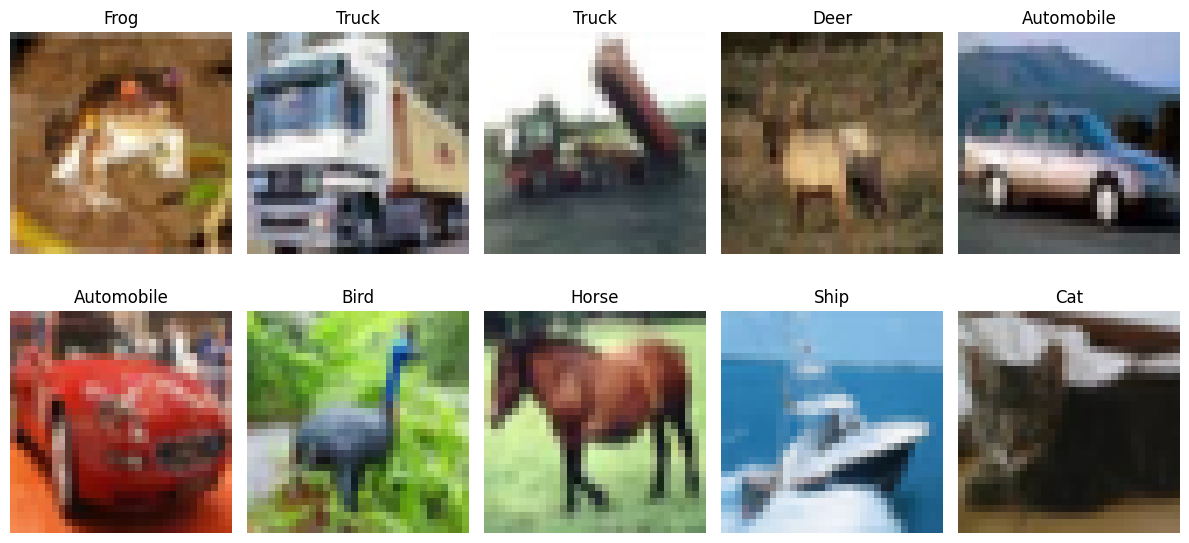

In [ ]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Normalize Images

In [ ]:
# Convert to float32
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Normalization Completed.")

Normalization Completed.


# One-Hot Encode Labels

In [ ]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(y_train_cat.shape)
print(y_test_cat.shape)

(50000, 10)
(10000, 10)


# Create Data Augmentation

In [ ]:
train_generator = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    zoom_range=0.10
)

train_generator.fit(X_train)

print("Data Augmentation Ready.")

Data Augmentation Ready.


# Build an Improved CNN Model

This CNN uses Batch Normalization and Dropout to improve accuracy and reduce overfitting.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)

model = Sequential([

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.30),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.40),

    # Fully Connected Layer
    Flatten(),

    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.50),

    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,345,066 (5.13 MB)

 Trainable params: 1,343,146 (5.12 MB)

 Non-trainable params: 1,920 (7.50 KB)

# Compile the Model

In [ ]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


# Define Callbacks

These callbacks improve training by:

*   Saving the best model
*   Stopping early if validation loss doesn't improve
*   Reducing the learning rate automatically






In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    checkpoint,
    earlystop,
    reduce_lr
]

# Train the Model

In [ ]:
history = model.fit(
    train_generator.flow(
        X_train,
        y_train_cat,
        batch_size=64
    ),
    epochs=15,
    validation_data=(X_test, y_test_cat),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8134 - loss: 0.5428
Epoch 1: val_accuracy did not improve from 0.83310
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.8132 - loss: 0.5415 - val_accuracy: 0.8032 - val_loss: 0.5898 - learning_rate: 0.0010
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8171 - loss: 0.5330
Epoch 2: val_accuracy did not improve from 0.83310
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.8191 - loss: 0.5293 - val_accuracy: 0.7827 - val_loss: 0.6550 - learning_rate: 0.0010
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8195 - loss: 0.5194
Epoch 3: val_accuracy did not improve from 0.83310
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.8170 - loss: 0.5261 - val_accuracy: 0.8318 - val_loss: 0.5024 - learning_rate: 0.0010
Epoch 4/15
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8209 - loss: 0.5130
Epoch 4: val_accuracy improved from 0.83310 to 0.85040, saving model t



# Save the Final Model


In [ ]:
model.save("cifar10_cnn_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


# Load the Best Mode

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model("best_model.keras")

print("Best model loaded successfully!")

Best model loaded successfully!


# Plot Training & Validation Accuracy

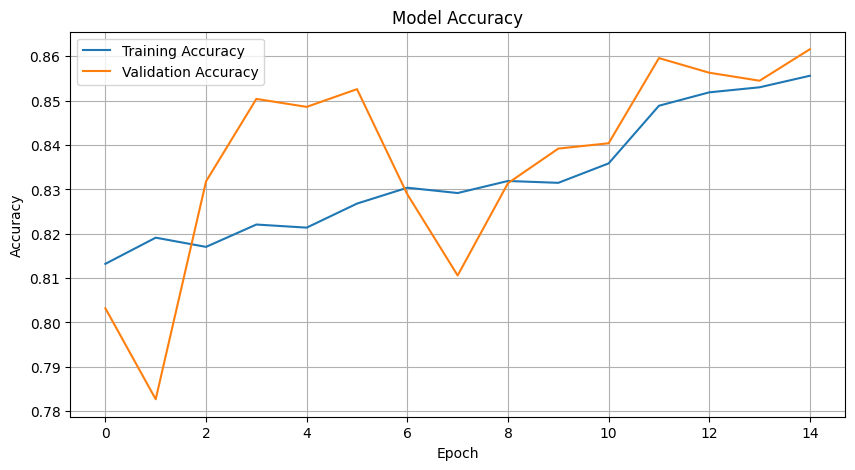

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# Plot Training & Validation Loss

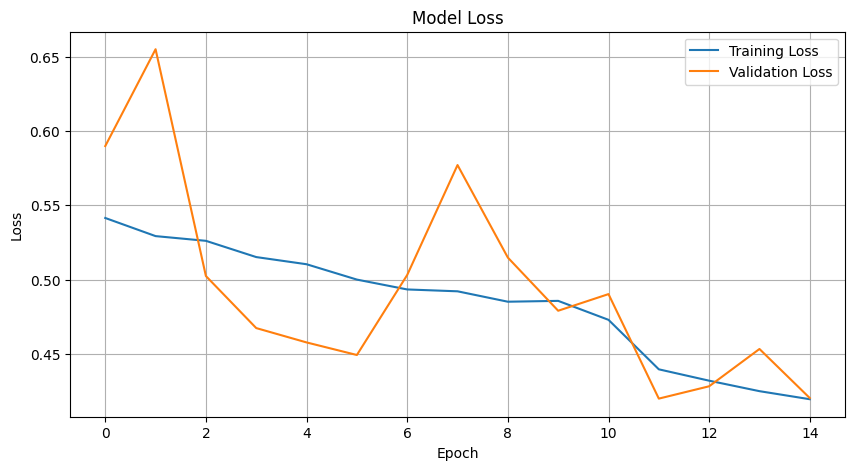

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# Evaluate Model on Test Dataset

In [ ]:
test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test_cat,
    verbose=1
)

print("="*40)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print("="*40)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8616 - loss: 0.4203
Test Loss     : 0.4203
Test Accuracy : 86.16%


# Predict Test Images

In [ ]:
y_pred_prob = best_model.predict(X_test)

y_pred = y_pred_prob.argmax(axis=1)

y_true = y_test.flatten()

print("Prediction Completed!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
Prediction Completed!


# Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    Airplane       0.89      0.88      0.88      1000
  Automobile       0.90      0.96      0.93      1000
        Bird       0.81      0.82      0.82      1000
         Cat       0.80      0.69      0.74      1000
        Deer       0.88      0.82      0.85      1000
         Dog       0.87      0.74      0.80      1000
        Frog       0.76      0.96      0.85      1000
       Horse       0.92      0.90      0.91      1000
        Ship       0.95      0.92      0.93      1000
       Truck       0.85      0.94      0.89      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



# Confusion Matrix

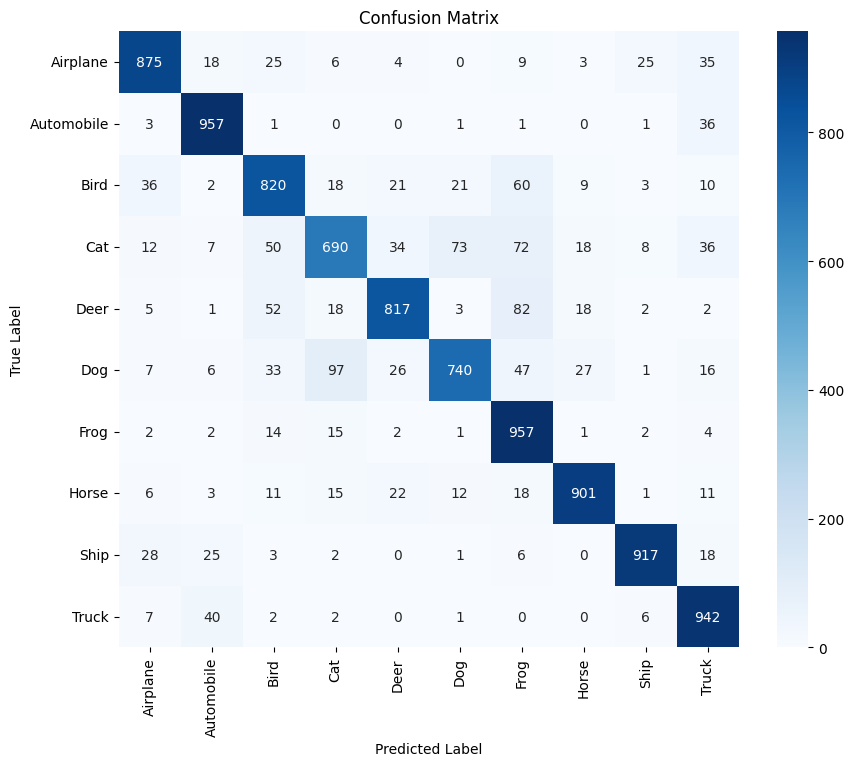

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

# Display Random Predictions

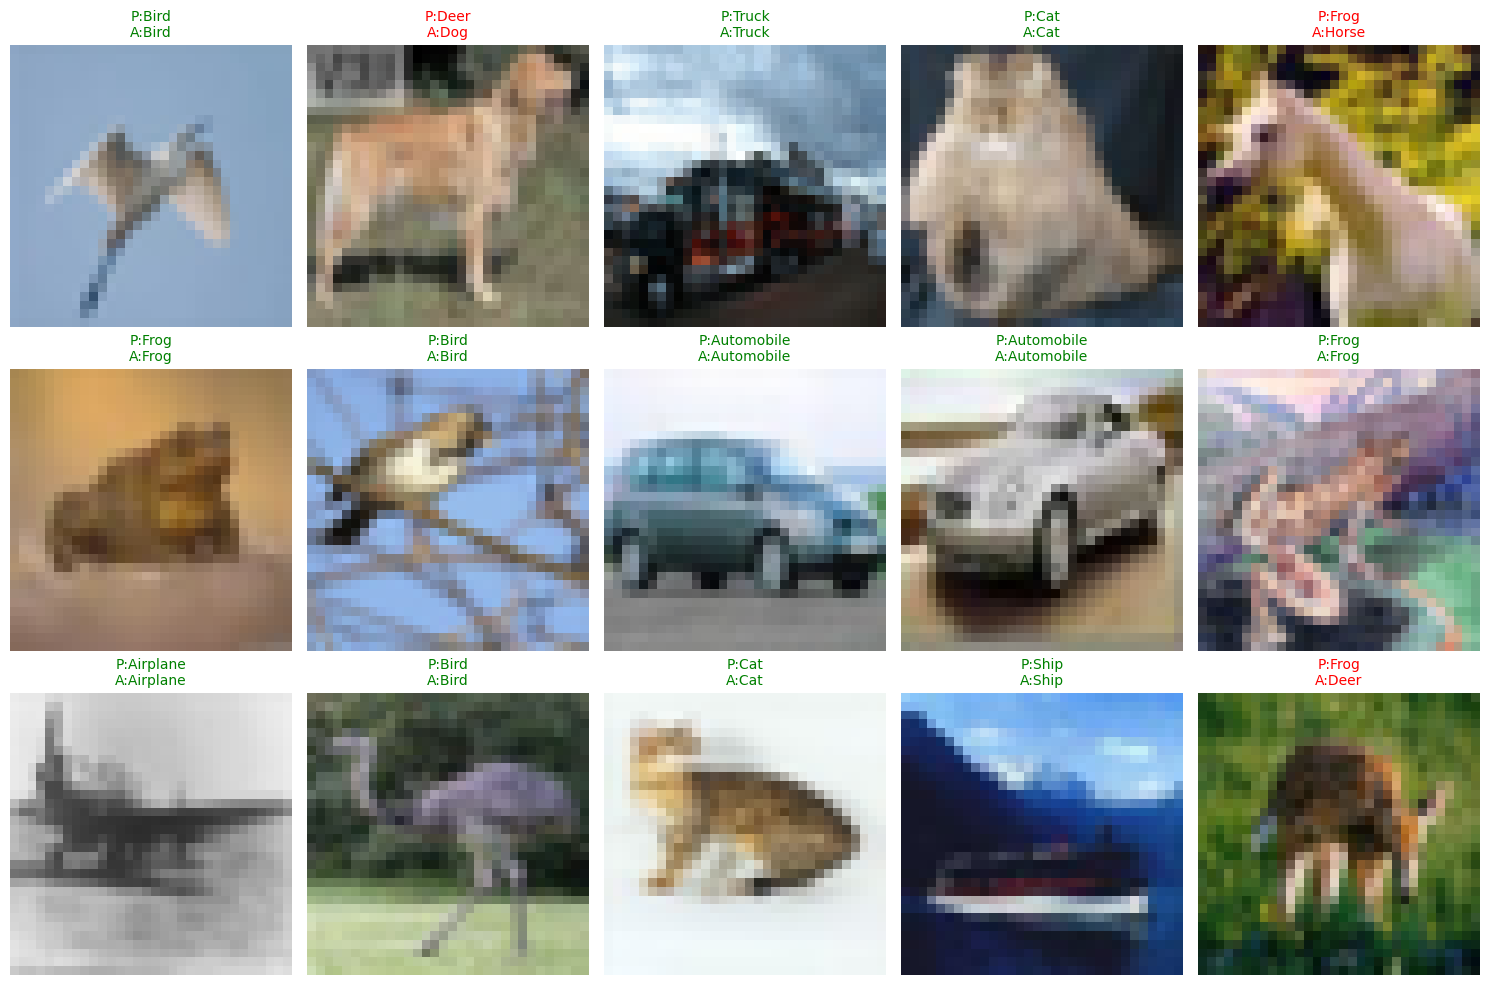

In [ ]:
import random

plt.figure(figsize=(15,10))

for i in range(15):

    index = random.randint(0, len(X_test)-1)

    plt.subplot(3,5,i+1)

    plt.imshow(X_test[index])

    predicted = class_names[y_pred[index]]

    actual = class_names[y_true[index]]

    color = "green" if predicted == actual else "red"

    plt.title(
        f"P:{predicted}\nA:{actual}",
        color=color,
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Predict a Single Test Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


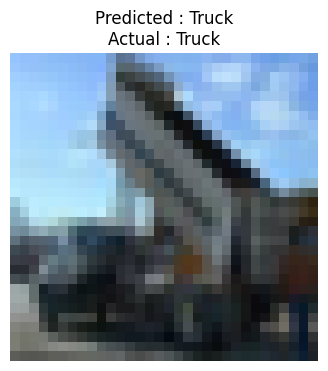

In [ ]:
index = 50

image = X_test[index]

prediction = best_model.predict(
    np.expand_dims(image, axis=0)
)

predicted_class = class_names[np.argmax(prediction)]

actual_class = class_names[y_true[index]]

plt.figure(figsize=(4,4))
plt.imshow(image)
plt.axis("off")

plt.title(
    f"Predicted : {predicted_class}\nActual : {actual_class}"
)

plt.show()

# Save Accuracy and Loss Values

In [ ]:
results = {
    "Training Accuracy": max(history.history["accuracy"]),
    "Validation Accuracy": max(history.history["val_accuracy"]),
    "Training Loss": min(history.history["loss"]),
    "Validation Loss": min(history.history["val_loss"]),
    "Test Accuracy": test_accuracy,
    "Test Loss": test_loss
}

for key, value in results.items():
    print(f"{key}: {value:.4f}")

Training Accuracy: 0.8556
Validation Accuracy: 0.8616
Training Loss: 0.4195
Validation Loss: 0.4200
Test Accuracy: 0.8616
Test Loss: 0.4203


# Save Results to CSV

In [ ]:
import pandas as pd

results_df = pd.DataFrame([results])

results_df.to_csv("performance_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


# Upload Your Own Image

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Zebra-finch-Taeniopygia-guttata-bird.webp to Zebra-finch-Taeniopygia-guttata-bird.webp


# Predict a Custom Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


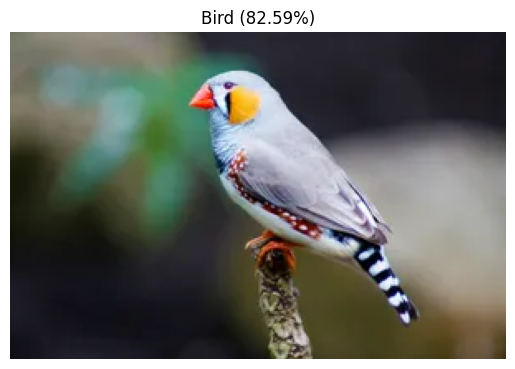

Prediction : Bird
Confidence : 82.59164


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Replace with your uploaded image name
image_path = "Zebra-finch-Taeniopygia-guttata-bird.webp"

img = image.load_img(image_path, target_size=(32,32))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = best_model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

plt.imshow(image.load_img(image_path))
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

print("Prediction :", predicted_class)
print("Confidence :", confidence)

# Download the Trained Model

In [ ]:
from google.colab import files

files.download("best_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Gradio web app

In [43]:
import gradio as gr
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import load_model

# ===============================
# Load Trained Model
# ===============================
model = load_model("best_model.keras")

# CIFAR-10 Classes
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

# ===============================
# Prediction Function
# ===============================
def predict(image):

    image = image.convert("RGB")
    image = image.resize((32, 32))

    img = np.array(image).astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img, verbose=0)[0]

    pred_class = class_names[np.argmax(prediction)]
    confidence = float(np.max(prediction) * 100)

    # Top-5 predictions
    top5 = np.argsort(prediction)[::-1][:5]

    results = {
        class_names[i]: float(prediction[i])
        for i in top5
    }

    # Probability Chart
    fig = plt.figure(figsize=(8,4))
    plt.bar(class_names, prediction)
    plt.xticks(rotation=45)
    plt.ylabel("Probability")
    plt.title("Prediction Probabilities")
    plt.tight_layout()

    return (
        pred_class,
        f"{confidence:.2f}%",
        results,
        fig
    )





# ===============================
# Interface
# ===============================

with gr.Blocks(theme=gr.themes.Soft(), title="CIFAR-10 Image Classification") as demo:

    gr.Markdown(
        """
# 🖼️ CIFAR-10 Image Classification

Deep Learning Project using **TensorFlow + CNN**

Upload an image and the model will classify it into one of the **10 CIFAR-10 classes**.
"""
    )

    with gr.Row():

        with gr.Column():

            input_image = gr.Image(
                type="pil",
                label="Upload Image"
            )

            predict_btn = gr.Button(
                "🔍 Predict",
                variant="primary"
            )

        with gr.Column():

            predicted_label = gr.Textbox(
                label="Predicted Class"
            )

            confidence = gr.Textbox(
                label="Confidence"
            )

            probabilities = gr.Label(
                num_top_classes=5,
                label="Top Predictions"
            )

    chart = gr.Plot(label="Prediction Probability Chart")




    predict_btn.click(
        fn=predict,
        inputs=input_image,
        outputs=[
            predicted_label,
            confidence,
            probabilities,
            chart
        ]
    )

demo.launch(share=True)

/tmp/ipykernel_1997/1962886881.py:73: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="CIFAR-10 Image Classification") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://408aff4d7783aa6193.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
